# Analisis Pola Peminjaman (Apriori)

Notebook ini digunakan untuk evaluasi hasil association rules pada data peminjaman perpustakaan.


## Tujuan Analisis

1. Memvalidasi bahwa data transaksi dapat diproses menjadi basket/itemset.
2. Menjalankan Apriori dengan parameter terukur.
3. Meninjau aturan asosiasi yang terbentuk.
4. Mengevaluasi dampak parameter terhadap jumlah aturan.


In [1]:
from pathlib import Path
import sys
from itertools import product
import matplotlib.pyplot as plt

def find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "apriori.py").exists():
            return p
    raise FileNotFoundError("apriori.py tidak ditemukan")

ROOT = find_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from apriori import apriori, load_transactions_from_csv
print("Project root:", ROOT)


Project root: D:\Koding\algoritma apriori


## 1) Pemilihan Dataset

Gunakan file contoh atau ganti `DATA_PATH` ke dataset operasional.


In [2]:
import csv
from collections import defaultdict

DATA_PATH = ROOT / "data" / "dataset_import_1000_transaksi.csv"

grouped = defaultdict(set)
with open(DATA_PATH, "r", encoding="utf-8-sig", newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        tx = row["transaction_id"].strip()
        dept = row["department_code"].strip()
        isbn = row["book_isbn"].strip()
        if tx and dept and isbn:
            grouped[tx].add(f"Jurusan:{dept}")
            grouped[tx].add(f"Buku:{isbn}")

transactions = [list(items) for items in grouped.values()]
print("Jumlah transaksi:", len(transactions))
print("Contoh transaksi pertama:", sorted(transactions[0]) if transactions else [])

Jumlah transaksi: 1000
Contoh transaksi pertama: ['Buku:978-1003', 'Buku:978-1004', 'Buku:978-1010', 'Jurusan:TI']


## 2) Eksekusi Apriori

Keterangan parameter:
- `min_support`: frekuensi minimum kemunculan pola.
- `min_confidence`: tingkat keandalan aturan.
- `min_lift`: kekuatan asosiasi terhadap baseline.


In [3]:
min_support = 0.30
min_confidence = 0.60
min_lift = 1.20

frequent_itemsets, rules = apriori(
    transactions=transactions,
    min_support=min_support,
    min_confidence=min_confidence,
    min_lift=min_lift,
)

print("Frequent itemsets:", len(frequent_itemsets))
print("Association rules (lolos filter):", len(rules))


Frequent itemsets: 0
Association rules (lolos filter): 0


In [4]:
top_n = 10
print("Top", top_n, "rules:")
for i, r in enumerate(rules[:top_n], start=1):
    left = ", ".join(r.antecedent)
    right = ", ".join(r.consequent)
    print(f"{i:02d}. IF [{left}] THEN [{right}] | support={r.support:.4f}, confidence={r.confidence:.4f}, lift={r.lift:.4f}")


Top 10 rules:


## 3) Evaluasi Sensitivitas Parameter

Bagian ini membandingkan jumlah aturan pada beberapa kombinasi parameter.


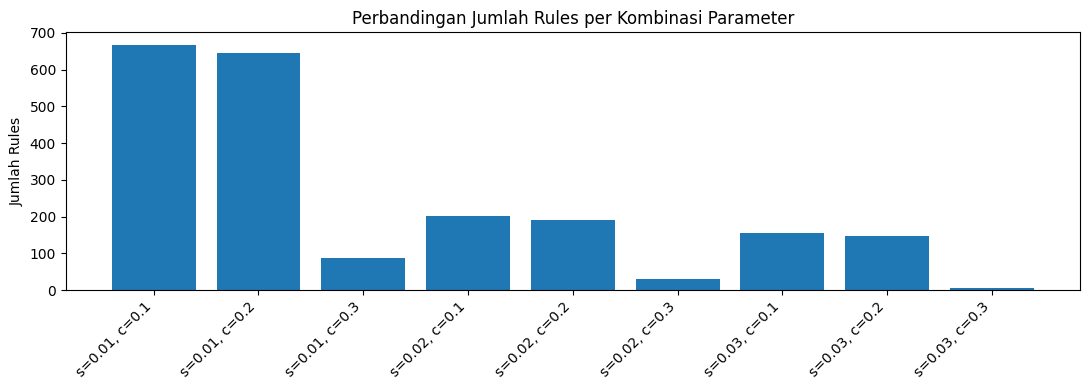

In [5]:
supports = [0.01, 0.02, 0.03]
confidences = [0.1, 0.2, 0.3]
compare_lift = 0.8

rows = []
for s, c in product(supports, confidences):
    _, rr = apriori(transactions, min_support=s, min_confidence=c, min_lift=compare_lift)
    rows.append({"label": f"s={s}, c={c}", "rules_count": len(rr)})

labels = [r["label"] for r in rows]
values = [r["rules_count"] for r in rows]

plt.figure(figsize=(11,4))
plt.bar(labels, values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Jumlah Rules")
plt.title("Perbandingan Jumlah Rules per Kombinasi Parameter")
plt.tight_layout()
plt.show()


## 4) Ringkasan Hasil

- Sistem menghasilkan aturan asosiasi dari transaksi peminjaman.
- Aturan dapat digunakan untuk analisis relasi jurusan dan koleksi.
- Parameter memengaruhi kuantitas dan kualitas aturan.
- Engine yang sama dapat digunakan pada aplikasi web operasional.
